# Practical Statistics for Data Scientists - Chapter 7
## Unsupervised Learning

This notebook covers dimensionality reduction with Principal Component Analysis (PCA), distance-based clustering with K-Means, Hierarchical Cluster Analysis (Dendrograms), and Model-Based Clustering (Gaussian Mixture Models).

### Environment Setup and Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## 1. Principal Component Analysis (PCA)

Reducing dimensional complexity by projecting feature variance onto orthogonal principal axes.

### Data Loading and Scaling
First, we load the stock market returns data and scale the features using `StandardScaler` to ensure that each feature contributes equally to the PCA.

In [3]:
sp500_px = pd.read_csv('drive/MyDrive/Colab Notebooks/data/sp500_data.csv', index_col=0)
syms = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'XOM', 'JNJ']
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms].dropna()

scaler = StandardScaler()
top_sp_scaled = scaler.fit_transform(top_sp)

### Fitting PCA Model
We fit a PCA model to the scaled data. The number of components is set to the number of original features for a complete analysis of variance.

In [4]:
pca = PCA(n_components=len(syms))
pca.fit(top_sp_scaled)

PCA(n_components=7)

### Visualizing Explained Variance (Scree Plot)
A scree plot helps visualize the proportion of variance explained by each principal component and the cumulative explained variance. This is crucial for determining the optimal number of components to retain.

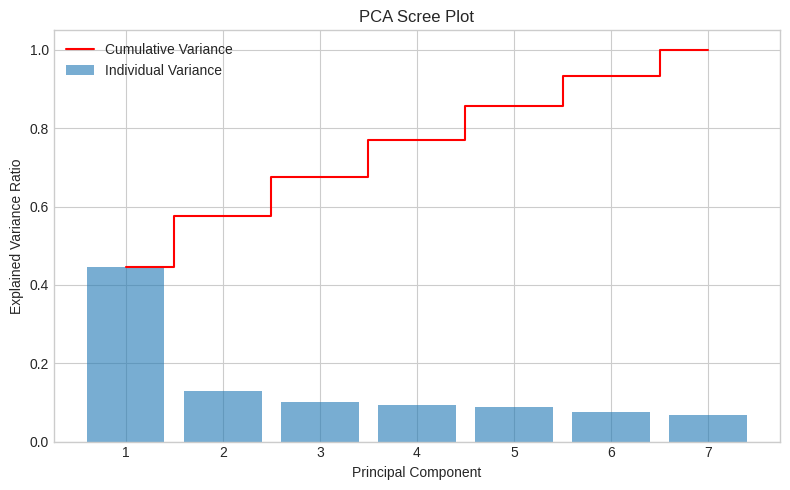

In [5]:
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(1, len(syms) + 1), explained_var, alpha=0.6, label='Individual Variance')
ax.step(range(1, len(syms) + 1), cum_var, where='mid', color='red', label='Cumulative Variance')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Scree Plot')
ax.legend()
plt.tight_layout()
plt.show()

---

## 2. K-Means Clustering

Partitioning data into $K$ distinct clusters by minimizing within-cluster sum of squares (inertia).

### Determining Optimal K with the Elbow Method
The elbow method is used to find the optimal number of clusters ($K$). We plot the inertia (sum of squared distances of samples to their closest cluster center) against the number of clusters. The "elbow" point in the plot indicates a good balance between the number of clusters and the explained variance.

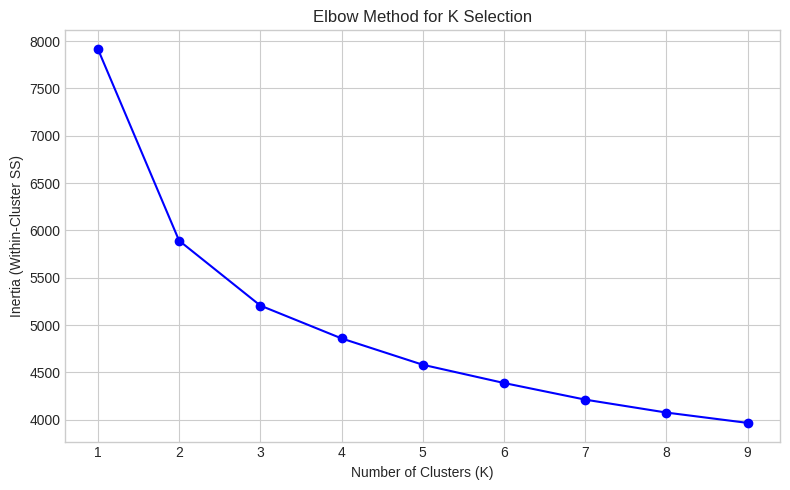

In [6]:
inertias = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(top_sp_scaled)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, 'bo-')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-Cluster SS)')
ax.set_title('Elbow Method for K Selection')
plt.tight_layout()
plt.show()

### Applying K-Means with Optimal K
Based on the elbow method (assuming $K=3$ from observation), we fit the final K-Means model and assign cluster labels to the original data.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(top_sp_scaled)
top_sp['Cluster'] = kmeans.labels_
print("Cluster Counts:")
print(top_sp['Cluster'].value_counts())

Cluster Counts:
Cluster
2    572
1    395
0    164
Name: count, dtype: int64


---

## 3. Hierarchical Cluster Analysis

Agglomerative clustering creating nested cluster hierarchies visualized via dendrograms.

### Dendrogram Visualization
Hierarchical clustering constructs a hierarchy of clusters. A dendrogram visually represents this hierarchy, showing how clusters are merged at different distance levels. Here, we apply Ward's method on the transpose of the scaled data to group stocks based on their co-movements.

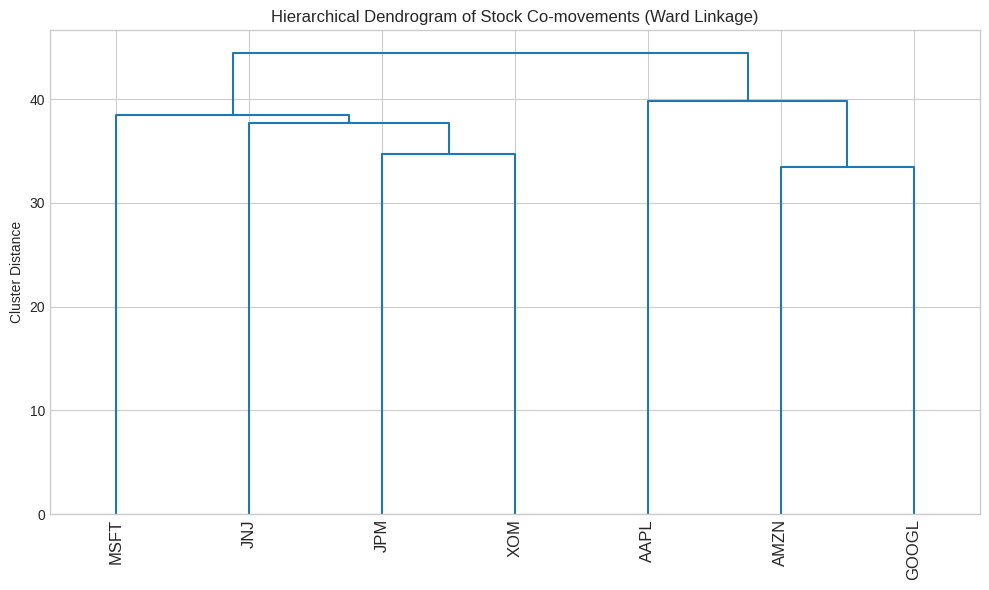

In [8]:
Z = linkage(top_sp_scaled.T, method='ward')

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Z, labels=syms, leaf_rotation=90, leaf_font_size=12, ax=ax)
ax.set_title('Hierarchical Dendrogram of Stock Co-movements (Ward Linkage)')
ax.set_ylabel('Cluster Distance')
plt.tight_layout()
plt.show()

---

## 4. Model-Based Clustering (Gaussian Mixture Models)

Soft clustering assuming data points are generated from a mixture of finite Gaussian distributions.

### Fitting Gaussian Mixture Model
Gaussian Mixture Models (GMMs) are probabilistic models that assume data points are generated from a mixture of several Gaussian distributions. Unlike K-Means, GMMs provide soft assignments (probabilities) for each data point belonging to each cluster.

In [9]:
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(top_sp_scaled)

GaussianMixture(n_components=3, random_state=42)

### Predicting Cluster Probabilities
After fitting the GMM, we can predict the probability that each data point belongs to each of the identified Gaussian components. This provides a 'soft' clustering assignment.

In [10]:
gmm_probs = gmm.predict_proba(top_sp_scaled)
print("Sample Soft Allocation Probabilities (First 5 Rows):")
print(pd.DataFrame(gmm_probs, columns=['Cluster 0', 'Cluster 1', 'Cluster 2']).head())

Sample Soft Allocation Probabilities (First 5 Rows):
   Cluster 0  Cluster 1  Cluster 2
0   0.075889   0.009088   0.915023
1   0.049063   0.005145   0.945792
2   0.108541   0.010976   0.880483
3   0.769402   0.077734   0.152864
4   0.017602   0.013982   0.968416
